C:\Users\toufi\AppData\Local\Temp\ipykernel_20128\453245895.py:17: DtypeWarning: Columns (0: ts_g, 1: aplicom_g, 2: address_g, 3: advdata_g, 4: geom_g, 5: source_g) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("HAZARD_FEATURE_DATASET.csv")


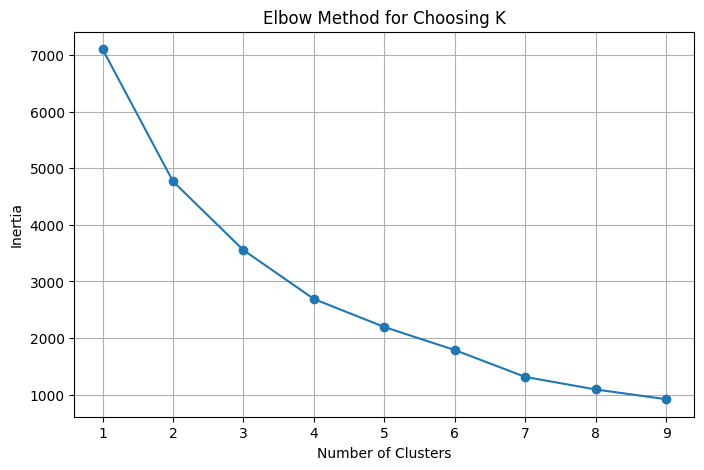

Cluster labeling completed!
    hazard_id  gps_speed_mean  gps_speed_min  accx_5s_mean_mean  \
0  18615183.0        0.017487            0.0         939.600000   
1  18615186.0        0.017588            0.0         928.102564   
2  18615187.0        0.018207            0.0         917.088889   
3  18615189.0        0.018937            0.0         889.196078   
4  18615192.0        0.035400            0.0         901.666667   

   accx_5s_min_min  grip_mean  water_layer_thickness_mean  \
0            680.0   0.684492                    0.405166   
1            680.0   0.684068                    0.407505   
2            680.0   0.683629                    0.410095   
3            680.0   0.683617                    0.410153   
4            672.0   0.666491                    0.653278   

   ice_layer_thickness_mean  snow_layer_thickness_mean  black_ice_risk_mean  \
0                       0.0                        0.0                  0.0   
1                       0.0                 

In [1]:
# ======================================================
#   HAZARD CLASSIFICATION WITH K-MEANS (FULL PIPELINE)
#   Works on HAZARD_FEATURE_DATASET.csv
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------------------
# STEP 1 — Load Hazard Feature Dataset
# ------------------------------------------------------

df = pd.read_csv("HAZARD_FEATURE_DATASET.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["hazard_time"] = pd.to_datetime(df["hazard_time"], utc=True)

# Time offset relative to hazard moment
df["t_offset"] = (df["timestamp"] - df["hazard_time"]).dt.total_seconds()


# ------------------------------------------------------
# STEP 2 — Aggregate one feature vector per hazard_id
# ------------------------------------------------------

features = df.groupby("hazard_id").agg({
    "gps_speed": ["mean", "min"],
    "accx_5s_mean": "mean",
    "accx_5s_min": "min",
    "grip": "mean",
    "water_layer_thickness": "mean",
    "ice_layer_thickness": "mean",
    "snow_layer_thickness": "mean",
    "black_ice_risk": "mean"
})

# Flatten columns
features.columns = ['_'.join(col).strip() for col in features.columns]
features.reset_index(inplace=True)


# ------------------------------------------------------
# STEP 3 — Fix missing data (required for K-means)
# ------------------------------------------------------

features = features.fillna(features.median())


# ------------------------------------------------------
# STEP 4 — Scale features
# ------------------------------------------------------

scaler = StandardScaler()
X = scaler.fit_transform(features.iloc[:, 1:])   # exclude hazard_id


# ------------------------------------------------------
# STEP 5 — Determine optimal number of clusters (Elbow)
# ------------------------------------------------------

inertias = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid()
plt.show()


# ------------------------------------------------------
# STEP 6 — Fit K-means with chosen K
# ------------------------------------------------------
# Choose K based on elbow plot
k = 4   # <-- change this if needed

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
features["cluster"] = kmeans.fit_predict(X)

print("Cluster labeling completed!")
print(features.head())


# ------------------------------------------------------
# STEP 7 — Attach cluster labels back to feature dataset
# ------------------------------------------------------

df_labeled = df.merge(
    features[["hazard_id", "cluster"]],
    on="hazard_id",
    how="left"
)

print(df_labeled.head())


# ------------------------------------------------------
# STEP 8 — Save labeled datasets
# ------------------------------------------------------

features.to_csv("HAZARD_CLUSTER_TABLE.csv", index=False)
df_labeled.to_csv("HAZARD_FEATURE_DATASET_LABELED.csv", index=False)

print("Saved:")
print(" - HAZARD_CLUSTER_TABLE.csv")
print(" - HAZARD_FEATURE_DATASET_LABELED.csv")